# SKA drift scan across Band 1: a frequency sweep (experiment 005)

Experiments 001–004 all sat at **350 MHz**, the bottom edge of SKA-Mid Band 1.
This notebook repeats the **off-plane** drift geometry of experiment 001
(b ≈ +50°) at five equally spaced channels spanning the whole band —
**350, 525, 700, 875, 1050 MHz** — holding everything else fixed: same Karoo
site, same parked azimuth, same three elevations on three sidereal nights,
same 3 h of 2 s samples, same noise model and seeds, same map-making recipe.

Only the frequency moves, but two things follow it, and separating them is the
point of the experiment:

1. **The beam narrows** as $1.22\,\lambda/D$: 3.99° at 350 MHz → 1.33° at
   1050 MHz. The elevation ladder (52°/50°/48°, i.e. 2° Dec steps) was chosen
   as *half-beam* spacing at 350 MHz — so above ~600 MHz the three Dec strips
   stop overlapping and the observed patch breaks into disjoint ribbons.
2. **Does the sky signal's temporal band move with it?** A parked dish crosses
   the beam in $\mathrm{FWHM}/(15°\,\mathrm{hr}^{-1})$ — 957 s at 350 MHz but
   319 s at 1050 MHz — suggesting the sky band should climb from ~1.0 to
   ~3.1 mHz, **cross the 2 mHz high-pass cutoff** this series has used
   throughout, and flip the filter's verdict. This sweep measures it, and
   **the answer is no**: the sky spectrum is essentially unchanged across the
   band. That refutation is one of the more useful things here.
   (The +36% high-pass penalty quoted in `HANDOFF.md` is the *galactic-plane*
   drift, experiment 003 — off-plane at nside 64 the same filter already
   *helped* slightly, 1299.9 → 1173.6 mK. The sweep is cross-checked against
   that run below.)

Everything is solved on a **single nside 128 grid** so map-space residuals are
comparable across channels — per-pixel RMS is *not* comparable across different
grids (see `HANDOFF.md`). nside 128 keeps ≥ 2.9 px across the FWHM everywhere;
the top channel is re-run at nside 256 at the end as a check that the grid is
not what limits it.

**Gaussian beam only.** The tapered-aperture sidelobe question is a bright-field
result and this field is off-plane, so the sweep follows the same choice made
for the off-plane raster in `ska_results_summary.ipynb`.

The expensive steps (TOD simulation + operator construction, ~1.5 h) live in
`ska_freq_sweep.py` and are cached — warm them from the shell with
`./run_freq_sweep.sh` before running this notebook.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'DSA')))

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation
from astropy import units as u

import ska_freq_sweep as S
from ska_common import (SKA_LAT, SKA_LON, SKA_HGT, ska_beam_fwhm_deg,
                        gdsm_equatorial_sky_model, azel_to_radec,
                        save_results_pdf)

CHANNELS = S.CHANNELS_MHZ
NS = S.NSIDE_SWEEP

# Frequency is an ORDERED variable, so the channels get a sequential ramp
# rather than categorical hues — the eye should read 350 -> 1050 as a
# progression. Okabe-Ito (colourblind-safe, as elsewhere in this series) is
# kept for the genuinely categorical splits: filter on/off and budget terms.
CH_COLORS = dict(zip(CHANNELS, plt.cm.viridis(np.linspace(0.12, 0.88,
                                                          len(CHANNELS)))))
C_NOHP, C_HP = "#0072B2", "#D55E00"
C_FLOOR, C_WHITE, C_1F = "#0072B2", "#009E73", "#D55E00"
C_FIXED = "#CC79A7"   # Okabe-Ito reddish purple

os.makedirs("figures", exist_ok=True)

## What changes with frequency, before any simulation

Two ratios decide the experiment, and both are pure geometry:

- **px/FWHM** — the map grid's sampling of the beam. `HANDOFF.md` records ~3 as
  the floor: at 2.2 px/FWHM the reconstruction degrades badly and the high-pass
  verdict even flips sign, which is how you tell an undersampled grid from a
  merely blunt one.
- **Dec step / FWHM** — the elevation ladder's 2° spacing measured in beams.
  Below 1 the three nightly strips overlap into a filled patch; above 1 they
  separate into ribbons with unobserved gaps between them.

The third column, the **beam edge** $1/(\mathrm{beam\ crossing\ time})$, is
the highest temporal frequency the beam can transfer — anything finer is
smoothed away. It is tempting to read it as "where the sky signal sits" and
compare it against the high-pass cutoff. That reading is **wrong**, and the
measured spectrum below shows why.

In [2]:
# Pure geometry — no simulation needed for any of this.
print(f"{'freq':>6s} {'FWHM':>8s} {'px/FWHM':>9s} {'beam edge':>12s} "
      f"{'Dec step/FWHM':>15s}")
geom = {}
for f in CHANNELS:
    fwhm = ska_beam_fwhm_deg(f)
    fcross = S.beam_crossing_freq_hz(f)
    geom[f] = dict(fwhm=fwhm, px_per_fwhm=S.px_per_fwhm(f, NS),
                   fcross=fcross, dec_step_per_fwhm=2.0 / fwhm)
    print(f"{f:6d} {fwhm:7.2f}° {geom[f]['px_per_fwhm']:9.1f} "
          f"{fcross * 1e3:9.2f} mHz {geom[f]['dec_step_per_fwhm']:15.2f}")

print(f"\nSampling floor is ~3 px/FWHM. nside {NS} clears it up to "
      f"{[f for f in CHANNELS if geom[f]['px_per_fwhm'] >= 3][-1]} MHz and "
      f"sits ON the floor at {CHANNELS[-1]} MHz "
      f"({min(g['px_per_fwhm'] for g in geom.values()):.1f} px/FWHM) — which "
      f"is why that channel is re-checked at nside {S.NSIDE_CHECK} below.")
gapped = [f for f in CHANNELS if geom[f]['dec_step_per_fwhm'] > 1.0]
print(f"Dec strips still overlap at "
      + ", ".join(f"{f} MHz" for f in CHANNELS if f not in gapped)
      + f"; they separate into ribbons at "
      + ", ".join(f"{f} MHz" for f in gapped) + ".")

  freq     FWHM   px/FWHM    beam edge   Dec step/FWHM
   350    3.99°       8.7      1.05 mHz            0.50
   525    2.66°       5.8      1.57 mHz            0.75
   700    2.00°       4.4      2.09 mHz            1.00
   875    1.60°       3.5      2.62 mHz            1.25
  1050    1.33°       2.9      3.14 mHz            1.50

Sampling floor is ~3 px/FWHM. nside 128 clears it up to 875 MHz and sits ON the floor at 1050 MHz (2.9 px/FWHM) — which is why that channel is re-checked at nside 256 below.
Dec strips still overlap at 350 MHz, 525 MHz; they separate into ribbons at 700 MHz, 875 MHz, 1050 MHz.


strip Dec centres: 7.41°, 9.41°, 11.41°


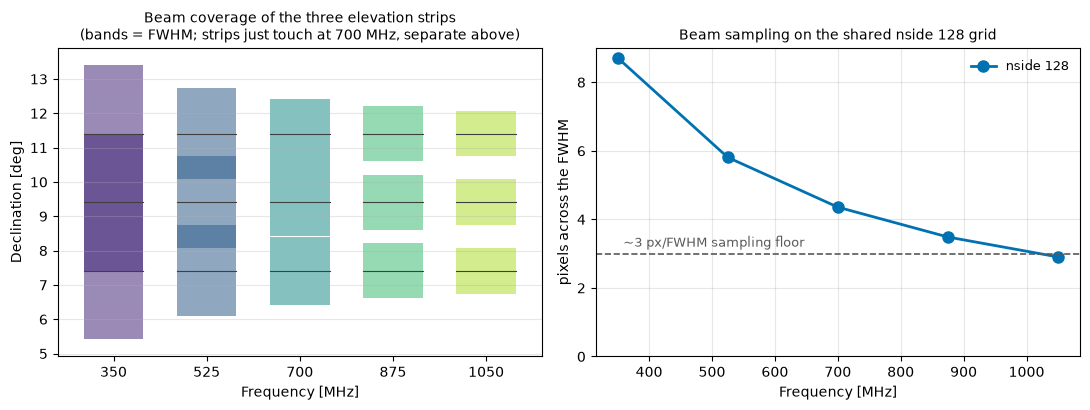

In [3]:
# Where the three strips actually sit on the sky, and how wide the beam is on
# each. Two panels rather than one with twin y-axes: the Dec geometry and the
# sampling ratio are different measures and a shared axis would imply a
# relationship that isn't there.
site = EarthLocation(lat=SKA_LAT * u.deg, lon=SKA_LON * u.deg,
                     height=SKA_HGT * u.m)

strip_dec = []
for n in S.nights():
    _, dec = azel_to_radec(S.DRIFT_AZ, n["el"], n["tlist"][::200],
                           S.START_UTC, site)
    strip_dec.append(float(np.mean(dec)))
print("strip Dec centres:", ", ".join(f"{d:.2f}°" for d in strip_dec))

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4.2))

x = np.arange(len(CHANNELS))
for i, f in enumerate(CHANNELS):
    half = geom[f]["fwhm"] / 2
    for j, dc in enumerate(strip_dec):
        axa.add_patch(plt.Rectangle((i - 0.32, dc - half), 0.64,
                                    2 * half, color=CH_COLORS[f],
                                    alpha=0.55, lw=0))
        axa.plot([i - 0.32, i + 0.32], [dc, dc], color="0.25", lw=0.8)
# add_patch does not autoscale, so set the limits from the geometry itself.
widest = max(geom[f]["fwhm"] for f in CHANNELS) / 2
axa.set_xlim(-0.6, len(CHANNELS) - 0.4)
axa.set_ylim(min(strip_dec) - widest - 0.5, max(strip_dec) + widest + 0.5)
axa.set_xticks(x)
axa.set_xticklabels([f"{f}" for f in CHANNELS])
axa.set_xlabel("Frequency [MHz]")
axa.set_ylabel("Declination [deg]")
axa.set_title("Beam coverage of the three elevation strips\n"
              "(bands = FWHM; strips just touch at 700 MHz, "
              "separate above)", fontsize=10)
axa.grid(alpha=0.3, axis="y")

axb.plot(CHANNELS, [geom[f]["px_per_fwhm"] for f in CHANNELS], "o-",
         color=C_NOHP, lw=2, ms=8, label=f"nside {NS}")
axb.axhline(3.0, color="0.35", ls="--", lw=1.2)
axb.annotate("~3 px/FWHM sampling floor", (CHANNELS[0], 3.0),
             textcoords="offset points", xytext=(4, 5), fontsize=9,
             color="0.35")
axb.set_xlabel("Frequency [MHz]")
axb.set_ylabel("pixels across the FWHM")
axb.set_title(f"Beam sampling on the shared nside {NS} grid", fontsize=10)
axb.set_ylim(0, None)
axb.legend(frameon=False, fontsize=9)
axb.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("figures/freqsweep_geometry.png", dpi=200, bbox_inches="tight")
plt.show()

## Load the cached channels and solve

Both heavy steps are cached by `ska_freq_sweep.py`, so this cell is a re-solve,
not a re-simulation. Each channel is solved four ways so the residual can be
decomposed: the full TOD, and the TOD with the 1/f, the white, or both noise
terms switched off. The draws are replayed from the same seeded stream
`generate_TOD` used, which is what makes the decomposition exact rather than
statistical.

The prior recipe is unchanged from experiments 001–004: beam-smoothed truth as
the prior mean (smoothed with that channel's own FWHM), $\sigma = \mathrm{std}$
of the patch truth, explicit per-sample noise variance.

In [4]:
gain_noise, white_noise = S.replay_noise()


def tod_variants(sky):
    '''Switch each noise component on/off around a fixed sky TOD.'''
    r = range(len(sky))
    return {
        "full":     [sky[i] * (1 + gain_noise[i]) * (1 + white_noise[i]) for i in r],
        "no 1/f":   [sky[i] * (1 + white_noise[i]) for i in r],
        "no white": [sky[i] * (1 + gain_noise[i]) for i in r],
        "clean":    [sky[i] for i in r],
    }


def solve(mm, TOD_group, prior_mean, truth, cutoff=None):
    '''The series' standard Wiener solve, high-pass cutoff exposed.'''
    nv_floor = S.WHITE_VAR * (1e-3 * float(np.mean(truth)))**2
    kw = dict(
        TOD_group=TOD_group, dtime=S.DT, Tsky_prior_mean=prior_mean,
        Tsky_prior_inv_cov_diag=np.ones_like(truth)
        / max(float(np.std(truth)), 1e-3)**2,
        noise_variance=[S.WHITE_VAR * (np.asarray(op) @ truth)**2 + nv_floor
                        for op in mm.Tsys_operators],
        regularization=1e-12, return_full_cov=False)
    if cutoff is not None:
        kw.update(use_high_pass=True,
                  cutoff_freq_group=np.array([cutoff] * len(TOD_group)),
                  filter_order=2)
    return mm(**kw)[0]


def noise_inv_variance(mm, truth):
    nv_floor = S.WHITE_VAR * (1e-3 * float(np.mean(truth)))**2
    return [1.0 / (S.WHITE_VAR * (np.asarray(op) @ truth)**2 + nv_floor)
            for op in mm.Tsys_operators]


def mode_spectrum(mm, truth):
    '''Eigenvalues of A^T N^-1 A (no prior) — how many sky modes the strategy
    actually measures. HANDOFF.md establishes this, not the pixel count, as the
    figure of merit: the drift measured ~17 modes at 350 MHz however finely the
    patch was pixelated.'''
    A = np.vstack([np.asarray(op) for op in mm.Tsys_operators])
    Ninv = np.concatenate(noise_inv_variance(mm, truth))
    ev = np.linalg.eigvalsh(A.T @ (Ninv[:, None] * A))[::-1]
    return ev


CH = {}
for f in CHANNELS:
    tod = S.simulate_channel(f, NS)
    mm = S.build_operator(f, NS, tod)
    pix = mm.pixel_indices

    truth_full = gdsm_equatorial_sky_model(freq=f, nside=NS)
    truth = truth_full[pix]
    prior = hp.smoothing(truth_full, fwhm=np.radians(geom[f]["fwhm"]))[pix]

    # Strip the seeded noise back off to recover the pure sky TOD.
    sky = [np.asarray(t, np.float64)
           / ((1 + gain_noise[i]) * (1 + white_noise[i]))
           for i, t in enumerate(tod["TOD_group"])]
    variants = tod_variants(sky)

    est = {}
    for filt, cut in (("no HP", None), ("HP 2 mHz", S.HP_CUTOFF)):
        for name, tg in variants.items():
            est[(filt, name)] = solve(mm, tg, prior, truth, cutoff=cut)

    ev = mode_spectrum(mm, truth)
    CH[f] = dict(mm=mm, pix=pix, truth=truth, truth_full=truth_full,
                 sky=sky,
                 est=est, ev=ev, npix=len(pix),
                 eff_modes=float(ev.sum() / ev.max()),
                 n_modes=int((ev > 0.01 * ev.max()).sum()),
                 sky_mean=float(np.mean(truth)),
                 sky_struct=float(np.std(truth)))
    print(f"[{f} MHz] {len(pix):5d} px | sky {CH[f]['sky_mean']:7.2f} K mean, "
          f"{CH[f]['sky_struct']:6.2f} K rms | modes: "
          f"{CH[f]['eff_modes']:.1f} effective, {CH[f]['n_modes']} above 1%")

[350 MHz ns128] loaded cached TODs
[350 MHz ns128] loaded cached operator (1288 pixels)


[350 MHz]  1288 px | sky   20.58 K mean,   2.37 K rms | modes: 3.7 effective, 17 above 1%
[525 MHz ns128] loaded cached TODs
[525 MHz ns128] loaded cached operator (876 pixels)


[525 MHz]   876 px | sky    6.94 K mean,   0.70 K rms | modes: 6.7 effective, 27 above 1%
[700 MHz ns128] loaded cached TODs
[700 MHz ns128] loaded cached operator (716 pixels)


[700 MHz]   716 px | sky    3.19 K mean,   0.31 K rms | modes: 10.6 effective, 37 above 1%
[875 MHz ns128] loaded cached TODs
[875 MHz ns128] loaded cached operator (635 pixels)


[875 MHz]   635 px | sky    1.74 K mean,   0.17 K rms | modes: 14.9 effective, 46 above 1%
[1050 MHz ns128] loaded cached TODs
[1050 MHz ns128] loaded cached operator (567 pixels)


[1050 MHz]   567 px | sky    1.05 K mean,   0.10 K rms | modes: 19.0 effective, 55 above 1%


## Residuals across the band

Three metrics, because no single one is honest on its own:

- **per-pixel RMS** — legitimate but pessimistic; most of it lives in sub-beam
  modes the data never constrained.
- **beam-scale RMS** — the residual averaged onto cells about one beam across,
  keeping only cells entirely inside the patch. This is the fair scale, and the
  cell size is chosen per channel to track the shrinking beam.
- **residual / sky structure** — dimensionless. The sky itself dims as
  $\nu^{-2.7}$ across this band, so absolute temperatures fall for reasons that
  have nothing to do with the strategy; this ratio is what actually compares.

In [5]:
def cell_nside_for(fwhm_deg):
    '''Power-of-two nside whose pixel size is closest to one beam.'''
    cands = [n for n in (8, 16, 32, 64) if n <= NS]
    return min(cands,
               key=lambda n: abs(np.degrees(hp.nside2resol(n)) - fwhm_deg))


def beam_cells(pix, vals, ns_cell, nside=NS):
    '''Average onto ~one-beam cells, keeping only cells whose pixels all lie
    inside the patch so partially covered edge cells cannot bias the result.

    Note the criterion tightens as the grid refines — a cell needs 4x as many
    pixels inside the patch at nside 128 as at nside 64 — so beam-scale numbers
    are comparable across channels here (one shared grid) but not directly
    against the nside-64 values quoted in HANDOFF.md.'''
    full = np.zeros(hp.nside2npix(nside))
    hit = np.zeros(hp.nside2npix(nside), bool)
    full[pix], hit[pix] = vals, True
    order = hp.ring2nest(nside, np.arange(hp.nside2npix(nside)))
    fn, hn = np.zeros_like(full), np.zeros_like(hit)
    fn[order], hn[order] = full, hit
    k = (nside // ns_cell)**2
    fc, hc = fn.reshape(-1, k), hn.reshape(-1, k)
    keep = hc.all(axis=1)
    return fc[keep].mean(axis=1)


# The beam-tracking cell size has to step in powers of two (nside 16/32/64),
# which puts a kink in the curve that is an artefact of the stepping, not the
# physics. Report a FIXED cell alongside it so the comparison is unambiguous:
# 1.83 deg cells are exactly one beam at 700 MHz and a consistent angular scale
# everywhere else.
NS_CELL_FIXED = 32

rows = []
print(f"{'freq':>6s} {'cell':>6s} {'per-pixel [K]':>26s} "
      f"{'beam-scale [K]':>26s} {'resid/sky':>20s}")
print(f"{'':6s} {'':6s} {'no HP':>12s} {'HP 2mHz':>13s} "
      f"{'no HP':>12s} {'HP 2mHz':>13s} {'no HP':>9s} {'HP 2mHz':>10s}")
for f in CHANNELS:
    c = CH[f]
    ns_cell = cell_nside_for(geom[f]["fwhm"])
    c["ns_cell"] = ns_cell
    for filt in ("no HP", "HP 2 mHz"):
        resid = c["est"][(filt, "full")] - c["truth"]
        c[("pix", filt)] = float(np.std(resid))
        c[("beam", filt)] = float(np.std(beam_cells(c["pix"], resid, ns_cell)))
        c[("fixcell", filt)] = float(
            np.std(beam_cells(c["pix"], resid, NS_CELL_FIXED)))
        c[("rel", filt)] = c[("pix", filt)] / c["sky_struct"]
    print(f"{f:6d} {ns_cell:6d} {c[('pix', 'no HP')]:12.3f} "
          f"{c[('pix', 'HP 2 mHz')]:13.3f} {c[('beam', 'no HP')]:12.3f} "
          f"{c[('beam', 'HP 2 mHz')]:13.3f} {c[('rel', 'no HP')]:9.3f} "
          f"{c[('rel', 'HP 2 mHz')]:10.3f}")
    rows.append((f"{f} MHz", f"per-pixel {c[('pix', 'no HP')]:.3f} K, "
                 f"beam-scale {c[('beam', 'no HP')]:.3f} K, "
                 f"resid/sky {c[('rel', 'no HP')]:.3f}"))

print(f"\nfixed {np.degrees(hp.nside2resol(NS_CELL_FIXED)):.2f}deg cells "
      f"(no stepping): "
      + ", ".join(f"{f} MHz {CH[f][('fixcell', 'no HP')]:.3f} K"
                  for f in CHANNELS))
print(f"\ncell nside per channel tracks the beam: "
      + ", ".join(f"{f} MHz -> ns{CH[f]['ns_cell']} "
                  f"({np.degrees(hp.nside2resol(CH[f]['ns_cell'])):.2f}deg "
                  f"vs FWHM {geom[f]['fwhm']:.2f}deg)" for f in CHANNELS))

  freq   cell              per-pixel [K]             beam-scale [K]            resid/sky
                     no HP       HP 2mHz        no HP       HP 2mHz     no HP    HP 2mHz
   350     16        1.242         1.184        0.178         0.348     0.525      0.500
   525     32        0.314         0.314        0.182         0.172     0.452      0.451
   700     32        0.132         0.139        0.034         0.073     0.427      0.448
   875     32        0.072         0.075        0.017         0.034     0.437      0.451
  1050     64        0.045         0.045        0.028         0.031     0.457      0.457

fixed 1.83deg cells (no stepping): 350 MHz 0.725 K, 525 MHz 0.182 K, 700 MHz 0.034 K, 875 MHz 0.017 K, 1050 MHz 0.008 K

cell nside per channel tracks the beam: 350 MHz -> ns16 (3.66deg vs FWHM 3.99deg), 525 MHz -> ns32 (1.83deg vs FWHM 2.66deg), 700 MHz -> ns32 (1.83deg vs FWHM 2.00deg), 875 MHz -> ns32 (1.83deg vs FWHM 1.60deg), 1050 MHz -> ns64 (0.92deg vs FWHM 1.33deg)


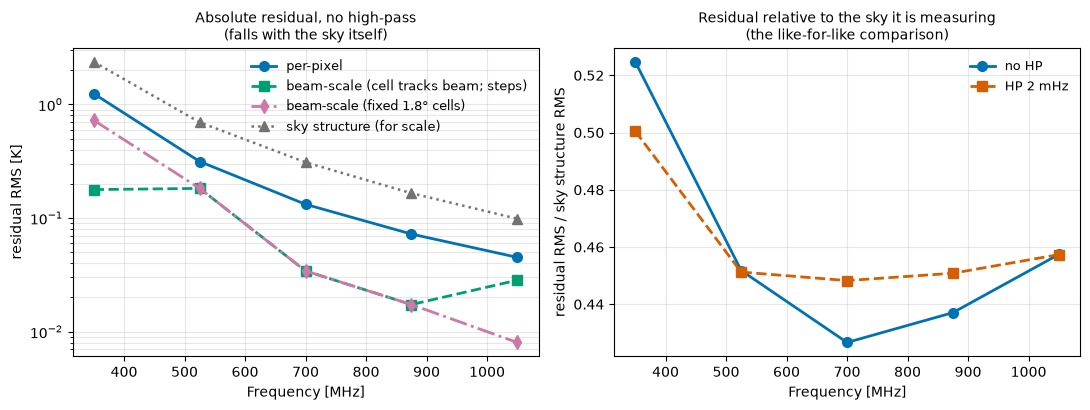

In [6]:
# Two panels: absolute temperature (which falls mostly because the sky dims)
# and the dimensionless ratio (which is the like-for-like comparison).
fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4.2))

axa.plot(CHANNELS, [CH[f][("pix", "no HP")] for f in CHANNELS], "o-",
         color=C_NOHP, lw=2, ms=7, label="per-pixel")
axa.plot(CHANNELS, [CH[f][("beam", "no HP")] for f in CHANNELS], "s--",
         color=C_WHITE, lw=2, ms=7,
         label="beam-scale (cell tracks beam; steps)")
axa.plot(CHANNELS, [CH[f][("fixcell", "no HP")] for f in CHANNELS], "d-.",
         color=C_FIXED, lw=2, ms=7,
         label=f"beam-scale (fixed "
               f"{np.degrees(hp.nside2resol(NS_CELL_FIXED)):.1f}$\\degree$ "
               f"cells)")
axa.plot(CHANNELS, [CH[f]["sky_struct"] for f in CHANNELS], "^:",
         color="0.45", lw=1.8, ms=7, label="sky structure (for scale)")
axa.set_yscale("log")
axa.set_xlabel("Frequency [MHz]")
axa.set_ylabel("residual RMS [K]")
axa.set_title("Absolute residual, no high-pass\n(falls with the sky itself)",
              fontsize=10)
axa.legend(frameon=False, fontsize=9)
axa.grid(alpha=0.3, which="both")

axb.plot(CHANNELS, [CH[f][("rel", "no HP")] for f in CHANNELS], "o-",
         color=C_NOHP, lw=2, ms=7, label="no HP")
axb.plot(CHANNELS, [CH[f][("rel", "HP 2 mHz")] for f in CHANNELS], "s--",
         color=C_HP, lw=2, ms=7, label="HP 2 mHz")
axb.set_xlabel("Frequency [MHz]")
axb.set_ylabel("residual RMS / sky structure RMS")
axb.set_title("Residual relative to the sky it is measuring\n"
              "(the like-for-like comparison)", fontsize=10)
axb.legend(frameon=False, fontsize=9)
axb.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("figures/freqsweep_residuals.png", dpi=200, bbox_inches="tight")
plt.show()

## The high-pass verdict, and a prediction that fails

The 2 mHz cutoff was chosen at 350 MHz, where the drift's sky power sits almost
entirely *below* it. Because the beam crossing time scales with the FWHM, the
band the beam can transfer climbs through the cutoff as the frequency rises,
crossing it near 700 MHz. The natural prediction is that the filter's verdict
flips sign there.

**Two things are wrong with that, and the sweep shows both.**

*The premise is wrong.* The sky TOD's power does **not** move with frequency.
Measured on the cached TODs, the median-power frequency is **0.28 mHz at every
channel** — the fundamental of the 1 h traverse — and ~93% of the power sits
below 2 mHz from 350 to 1050 MHz. Every higher percentile is flat too (90% at
1.67 mHz throughout; the 99% level, if anything, drifts slightly *down*).
Diffuse GDSM emission is red, so the large-scale gradient along the drift
dominates the spectrum no matter how narrow the beam gets. The beam crossing
time bounds the *support* of the sky signal, not where its power lives — and a
high-pass cares about the latter.

*The conclusion is wrong too, for a second and independent reason.* Even if the
band had moved, it governs a term that does not limit this map. Off-plane the
residual is **96–100% beam + prior floor and only 5–8% 1/f**, so perfectly
removing the 1/f term could not move the total by more than a few percent.

Both point the same way, and the measurement agrees: the effect is within ±5%
at every channel and does not track the crossover — the filter helps slightly
at 350 MHz, is neutral at 525 and 1050 MHz, and mildly *hurts* at 700 and
875 MHz. **Off-plane, the high-pass cutoff is simply not an important knob.**
It matters on the galactic plane, where 1/f is a far larger share of a far
larger residual.

**The coverage and filter effects are confounded by frequency, and separating
them takes care.** Both the Dec-gap threshold and the (putative) band crossover
scale as $1/\mathrm{FWHM}$, so with a 2° ladder and a 2 mHz cutoff they land
within ~30 MHz of each other, near 700 MHz. They are still separable, because
each has a comparison that holds the other fixed — the **no-HP** column sees
the coverage change with no filter involved at all, and the **HP-minus-no-HP
difference at a single channel** sees the filter at fixed coverage. Neither is
read from the total residual alone.


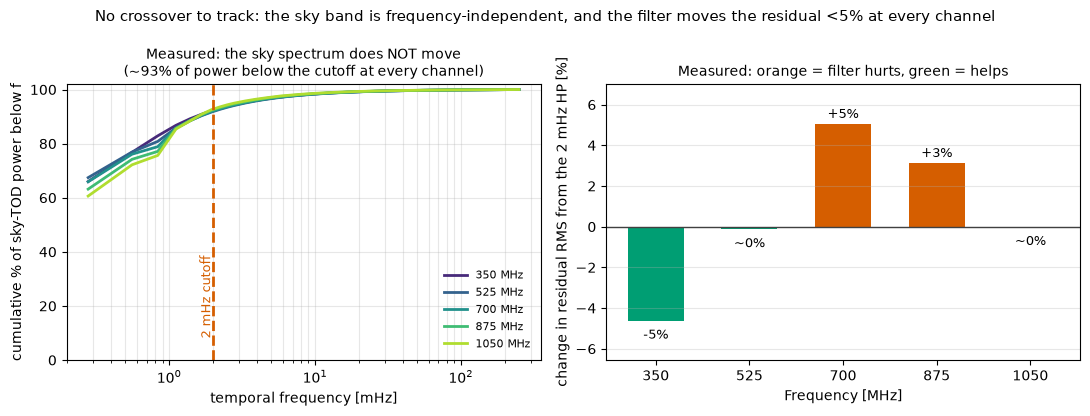

  freq  beam edge  median power  90% below  power < 2 mHz  HP effect
   350     1.05 mHz        0.28 mHz     1.67 mHz          93.0%      -4.6%
   525     1.57 mHz        0.28 mHz     1.67 mHz          92.7%      -0.1%
   700     2.09 mHz        0.28 mHz     1.67 mHz          92.9%      +5.1%
   875     2.62 mHz        0.28 mHz     1.67 mHz          93.2%      +3.1%
  1050     3.14 mHz        0.28 mHz     1.67 mHz          93.6%      -0.0%

The beam edge triples across the band; nothing in the measured spectrum moves with it.


In [7]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4.2))

# Panel A: the MEASURED sky-TOD spectrum, not the analytic beam edge. An
# earlier version of this figure plotted 1/(beam crossing time) here and called
# it "the sky signal band"; the measurement below refutes that reading, so the
# claim is now shown rather than asserted. The curves lie on top of each other:
# the sky spectrum does not move across the band.
band = {}
for f in CHANNELS:
    fr, cum, at = S.sky_band_percentiles(CH[f]["sky"])
    band[f] = (fr, cum, at)
    axa.semilogx(fr[1:] * 1e3, cum[1:] * 100, color=CH_COLORS[f], lw=2,
                 label=f"{f} MHz")
axa.axvline(S.HP_CUTOFF * 1e3, color=C_HP, ls="--", lw=2)
axa.annotate("2 mHz cutoff", (S.HP_CUTOFF * 1e3, 8), rotation=90,
             fontsize=9, color=C_HP, ha="right", va="bottom")
axa.set_xlabel("temporal frequency [mHz]")
axa.set_ylabel("cumulative % of sky-TOD power below f")
axa.set_title("Measured: the sky spectrum does NOT move\n"
              "(~93% of power below the cutoff at every channel)",
              fontsize=10)
axa.set_ylim(0, 102)
axa.legend(frameon=False, fontsize=8, loc="lower right")
axa.grid(alpha=0.3, which="both")

# Panel B: what the filter actually did to the residual.
delta = [(CH[f][("pix", "HP 2 mHz")] / CH[f][("pix", "no HP")] - 1) * 100
         for f in CHANNELS]
cols = [C_HP if d > 0 else C_WHITE for d in delta]
axb.bar([str(f) for f in CHANNELS], delta, 0.6, color=cols)
axb.axhline(0, color="0.25", lw=1)
for i, d in enumerate(delta):
    axb.annotate("~0%" if abs(d) < 0.5 else f"{d:+.0f}%", (i, d),
                 textcoords="offset points",
                 xytext=(0, 4 if d > 0 else -13), ha="center", fontsize=9)
axb.set_xlabel("Frequency [MHz]")
axb.set_ylabel("change in residual RMS from the 2 mHz HP [%]")
axb.set_title("Measured: orange = filter hurts, green = helps", fontsize=10)
axb.margins(y=0.20)
axb.grid(alpha=0.3, axis="y")

fig.suptitle("No crossover to track: the sky band is frequency-independent, "
             "and the filter moves the residual <5% at every channel",
             fontsize=11)
fig.tight_layout()
fig.savefig("figures/freqsweep_highpass.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"{'freq':>6s} {'beam edge':>10s} {'median power':>13s} "
      f"{'90% below':>10s} {'power < 2 mHz':>14s} {'HP effect':>10s}")
for f, d in zip(CHANNELS, delta):
    at = band[f][2]
    frac = band[f][1][np.searchsorted(band[f][0], S.HP_CUTOFF)] * 100
    print(f"{f:6d} {geom[f]['fcross']*1e3:8.2f} mHz {at[0.5]*1e3:11.2f} mHz "
          f"{at[0.9]*1e3:8.2f} mHz {frac:13.1f}% {d:+9.1f}%")
print("\nThe beam edge triples across the band; nothing in the measured "
      "spectrum moves with it.")

## Measured modes, and the coverage that feeds them

`HANDOFF.md` establishes the mode count — the eigenspectrum of
$A^{\mathsf{T}}N^{-1}A$ — as the figure of merit rather than the pixel count or
the integration time: at 350 MHz the drift measured ~17 independent sky modes
over its patch, and everything else in the map was prior.

A narrower beam cuts two ways here. It resolves finer structure, which should
*add* modes; but it also shrinks the observed patch and opens the Dec gaps,
which removes sky to measure. The sweep separates the two by reporting modes
both in absolute terms and per unit observed area.

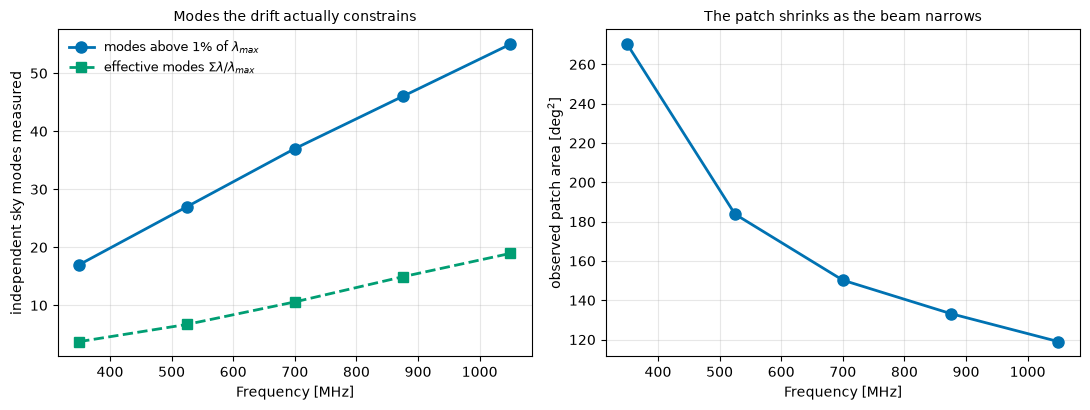

  freq   npix  area deg2   modes  modes/100deg2
   350   1288      270.3      17            6.3
   525    876      183.8      27           14.7
   700    716      150.2      37           24.6
   875    635      133.2      46           34.5
  1050    567      119.0      55           46.2


In [8]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4.2))

pix_area = hp.nside2pixarea(NS, degrees=True)
areas = np.array([CH[f]["npix"] * pix_area for f in CHANNELS])
nmodes = np.array([CH[f]["n_modes"] for f in CHANNELS], float)

axa.plot(CHANNELS, nmodes, "o-", color=C_NOHP, lw=2, ms=8,
         label="modes above 1% of $\\lambda_{max}$")
axa.plot(CHANNELS, [CH[f]["eff_modes"] for f in CHANNELS], "s--",
         color=C_WHITE, lw=2, ms=7,
         label="effective modes $\\Sigma\\lambda/\\lambda_{max}$")
axa.set_xlabel("Frequency [MHz]")
axa.set_ylabel("independent sky modes measured")
axa.set_title("Modes the drift actually constrains", fontsize=10)
axa.legend(frameon=False, fontsize=9)
axa.grid(alpha=0.3)

axb.plot(CHANNELS, areas, "o-", color=C_NOHP, lw=2, ms=8)
axb.set_xlabel("Frequency [MHz]")
axb.set_ylabel("observed patch area [deg$^2$]")
axb.set_title("The patch shrinks as the beam narrows", fontsize=10)
axb.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("figures/freqsweep_modes.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"{'freq':>6s} {'npix':>6s} {'area deg2':>10s} {'modes':>7s} "
      f"{'modes/100deg2':>14s}")
for f, a, m in zip(CHANNELS, areas, nmodes):
    print(f"{f:6d} {CH[f]['npix']:6d} {a:10.1f} {int(m):7d} "
          f"{m / a * 100:14.1f}")

## Noise budget across the band

The 1/f gain noise is *fractional* — the contamination it injects is
$g(t)\,T_\mathrm{sky}(t)$, so it scales with sky brightness and should fall
with it across the band. The beam + prior floor is set by what the strategy
fails to measure, which is a different mechanism. Decomposing the residual
shows which one runs the map at each frequency.

  freq    filter    total    floor    white      1/f  quad sum
   350     no HP    1.242    1.248    0.108    0.063     1.254
   350  HP 2 mHz    1.184    1.195    0.206    0.021     1.213
   525     no HP    0.314    0.311    0.052    0.022     0.316
   525  HP 2 mHz    0.314    0.293    0.123    0.014     0.318
   700     no HP    0.132    0.130    0.032    0.010     0.134
   700  HP 2 mHz    0.139    0.120    0.060    0.008     0.134
   875     no HP    0.072    0.071    0.019    0.005     0.073
   875  HP 2 mHz    0.075    0.064    0.033    0.004     0.072
  1050     no HP    0.045    0.043    0.011    0.002     0.045
  1050  HP 2 mHz    0.045    0.038    0.019    0.002     0.043


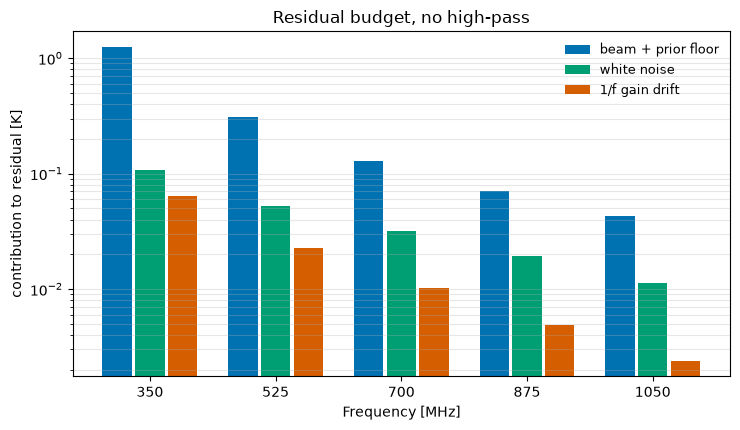

  350 MHz: floor is 100% of the residual; 1/f is 5%
  525 MHz: floor is 99% of the residual; 1/f is 7%
  700 MHz: floor is 98% of the residual; 1/f is 8%
  875 MHz: floor is 98% of the residual; 1/f is 7%
 1050 MHz: floor is 96% of the residual; 1/f is 5%


In [9]:
budget = {}
print(f"{'freq':>6s} {'filter':>9s} {'total':>8s} {'floor':>8s} "
      f"{'white':>8s} {'1/f':>8s} {'quad sum':>9s}")
for f in CHANNELS:
    c = CH[f]
    for filt in ("no HP", "HP 2 mHz"):
        e = c["est"]
        total = float(np.std(e[(filt, "full")] - c["truth"]))
        floor = float(np.std(e[(filt, "clean")] - c["truth"]))
        white = float(np.std(e[(filt, "no 1/f")] - e[(filt, "clean")]))
        onef = float(np.std(e[(filt, "full")] - e[(filt, "no 1/f")]))
        quad = float(np.sqrt(floor**2 + white**2 + onef**2))
        budget[(f, filt)] = dict(total=total, floor=floor, white=white,
                                 onef=onef)
        print(f"{f:6d} {filt:>9s} {total:8.3f} {floor:8.3f} {white:8.3f} "
              f"{onef:8.3f} {quad:9.3f}")

fig, ax = plt.subplots(figsize=(7.5, 4.4))
x = np.arange(len(CHANNELS))
w = 0.26
for j, (lbl, key, col) in enumerate((("beam + prior floor", "floor", C_FLOOR),
                                     ("white noise", "white", C_WHITE),
                                     ("1/f gain drift", "onef", C_1F))):
    ax.bar(x + (j - 1) * w, [budget[(f, "no HP")][key] for f in CHANNELS],
           w * 0.9, color=col, label=lbl)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([str(f) for f in CHANNELS])
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("contribution to residual [K]")
ax.set_title("Residual budget, no high-pass")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3, axis="y", which="both")
fig.tight_layout()
fig.savefig("figures/freqsweep_budget.png", dpi=200, bbox_inches="tight")
plt.show()

for f in CHANNELS:
    b = budget[(f, "no HP")]
    print(f"{f:5d} MHz: floor is {b['floor'] / b['total']:.0%} of the residual;"
          f" 1/f is {b['onef'] / b['total']:.0%}")

## The maps

One row per channel: truth, reconstruction, and residual on that channel's own
patch. The colour scale is per-row — the sky is ~7× brighter at 350 MHz than at
1050 MHz, so a shared scale would black out the top rows. Diverging about zero
for the residual, which has a sign; sequential for brightness.

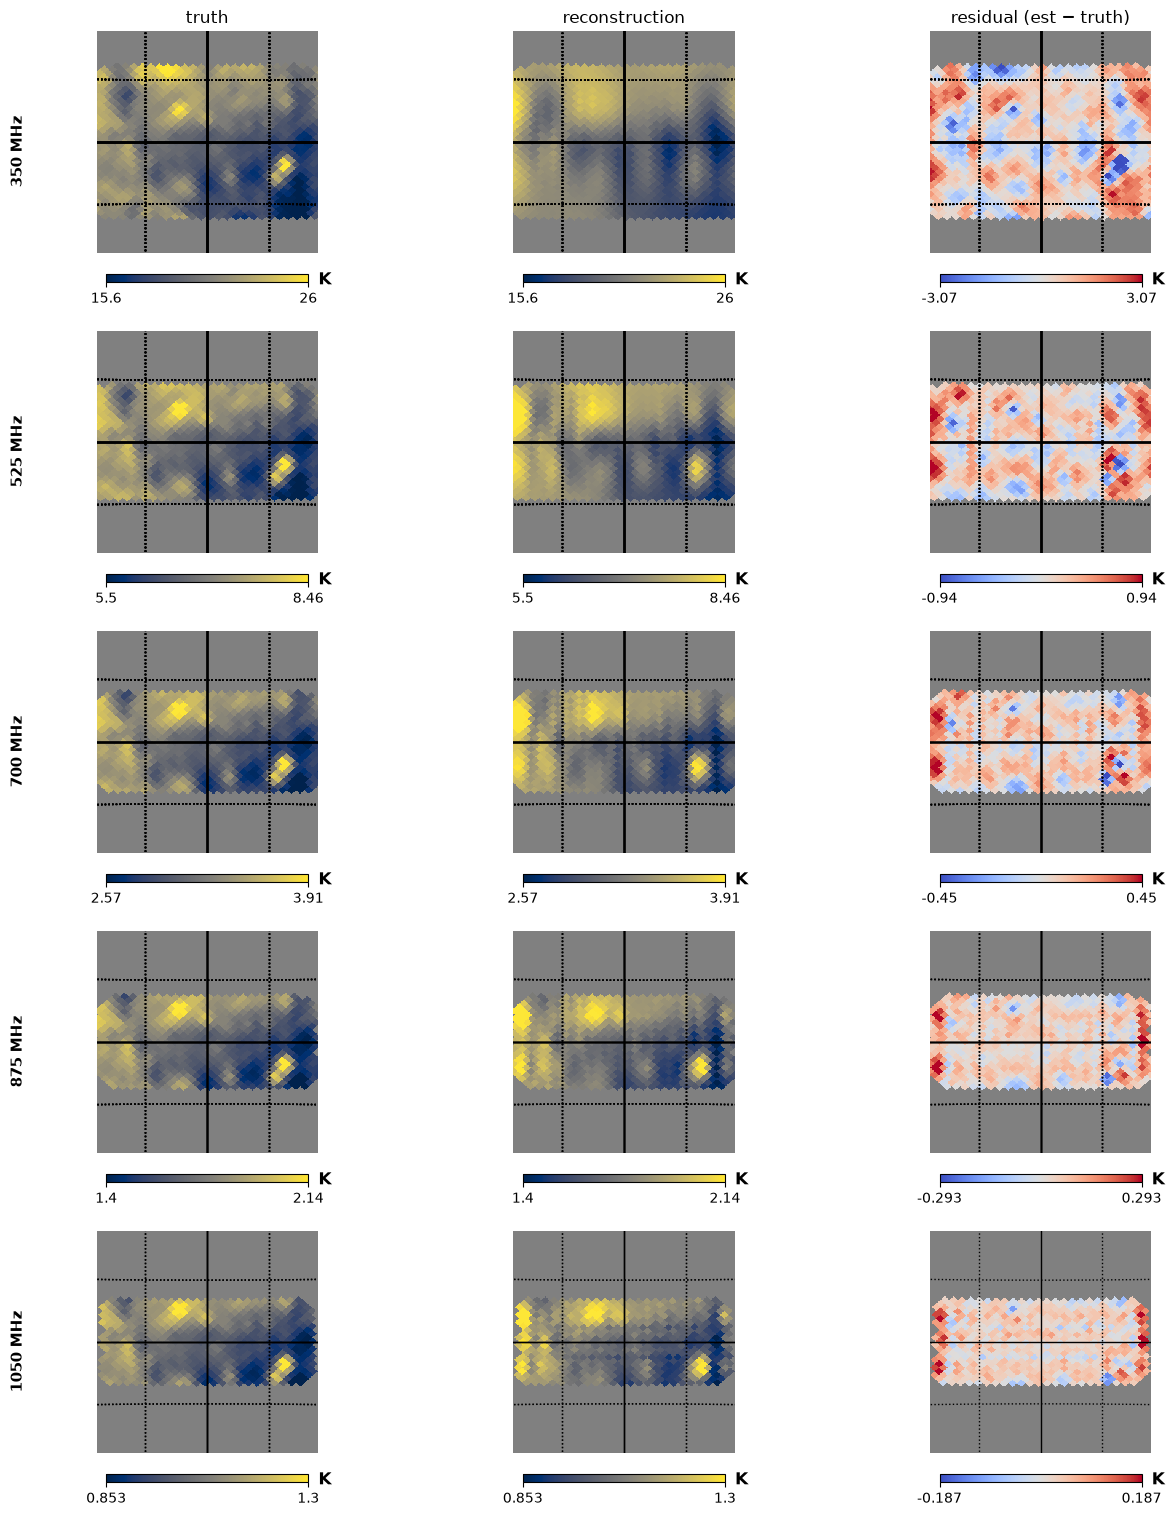

In [ ]:
def patch_centre(pix):
    v = np.array(hp.pix2vec(NS, pix)).mean(axis=1)
    lon, lat = hp.vec2dir(v, lonlat=True)
    return float(lon), float(lat)


def masked(pix, vals):
    m = np.full(hp.nside2npix(NS), hp.UNSEEN)
    m[pix] = vals
    return m


COLNAMES = ("truth", "reconstruction", "residual (est − truth)")
fig = plt.figure(figsize=(12.5, 3.0 * len(CHANNELS)))
for row, f in enumerate(CHANNELS):
    c = CH[f]
    resid = c["est"][("no HP", "full")] - c["truth"]
    lon, lat = patch_centre(c["pix"])
    vmin, vmax = np.percentile(c["truth"], [1, 99])
    rlim = float(np.percentile(np.abs(resid), 99))
    panels = [(c["truth"], "cividis", vmin, vmax),
              (c["est"][("no HP", "full")], "cividis", vmin, vmax),
              (resid, "coolwarm", -rlim, rlim)]
    for col, (vals, cmap, lo, hi) in enumerate(panels):
        hp.gnomview(masked(c["pix"], vals), rot=(lon, lat), reso=3.0,
                    xsize=360, min=lo, max=hi, cmap=cmap, notext=True,
                    title=COLNAMES[col] if row == 0 else "", unit="K",
                    sub=(len(CHANNELS), 3, row * 3 + col + 1),
                    fig=fig.number, cbar=True)
        p.graticule(dpar=5, dmer=5)

for row, f in enumerate(CHANNELS):
    fig.text(0.02, 1 - (row + 0.5) / len(CHANNELS), f"{f} MHz", rotation=90,
             va="center", ha="center", fontsize=11, weight="bold")
fig.subplots_adjust(left=0.05)
fig.savefig("figures/freqsweep_maps.png", dpi=160, bbox_inches="tight")
plt.show()

## Cross-check against experiment 001

The 350 MHz channel is the same field, geometry, seeds and recipe that
experiment 001 ran at **nside 64**. Only the grid differs, so the two must
agree on everything grid-independent — and `HANDOFF.md`'s central claim is
specifically that the **measured-mode count is grid-independent** (it found 17
modes at both nside 32 and nside 64). Reproducing that number on a third grid
is the sharpest available test of it.

In [11]:
# Solve experiment 001's cached nside-64 run with this notebook's own code, so
# the comparison cannot be an artefact of a different recipe.
import pickle

NS64 = 64
try:
    with open(f"mapmaker_ops_ska_drift_gauss_ns{NS64}.pkl", "rb") as fh:
        mm64 = pickle.load(fh)
    d64 = np.load("simulated_TODs_ska_drift_gauss.npz", allow_pickle=True)
    have64 = True
except FileNotFoundError:
    have64 = False
    print("experiment 001 caches not found - skipping the cross-check")

if have64:
    F0 = CHANNELS[0]
    pix64 = mm64.pixel_indices
    truth64_full = gdsm_equatorial_sky_model(freq=F0, nside=NS64)
    truth64 = truth64_full[pix64]
    prior64 = hp.smoothing(truth64_full,
                           fwhm=np.radians(geom[F0]["fwhm"]))[pix64]
    tg64 = [np.asarray(t, np.float64) for t in d64["TOD_group"]]
    e64 = {filt: solve(mm64, tg64, prior64, truth64, cutoff=cut)
           for filt, cut in (("no HP", None), ("HP 2 mHz", S.HP_CUTOFF))}
    ev64 = mode_spectrum(mm64, truth64)

    r64 = float(np.std(e64["no HP"] - truth64))
    r128 = CH[F0][("pix", "no HP")]
    hp64 = (float(np.std(e64["HP 2 mHz"] - truth64)) / r64 - 1) * 100
    hp128 = (CH[F0][("pix", "HP 2 mHz")] / r128 - 1) * 100

    print(f"{F0} MHz, same field and seeds, two grids\n")
    print(f"{'':>28s} {'nside 64':>10s} {'nside 128':>10s}")
    print(f"{'pixels solved':>28s} {len(pix64):10d} {CH[F0]['npix']:10d}"
          f"   ({CH[F0]['npix'] / len(pix64):.2f}x, 4x expected)")
    b64 = float(np.std(beam_cells(pix64, e64["no HP"] - truth64,
                                  CH[F0]["ns_cell"], nside=NS64)))
    print(f"{'per-pixel residual [K]':>28s} {r64:10.3f} {r128:10.3f}")
    print(f"{'beam-scale residual [K]':>28s} {b64:10.3f} "
          f"{CH[F0][('beam', 'no HP')]:10.3f}   (interior-cell criterion "
          f"tightens with the grid)")
    print(f"{'high-pass effect [%]':>28s} {hp64:+10.1f} {hp128:+10.1f}")
    print(f"{'modes above 1%':>28s} {int((ev64 > 0.01 * ev64.max()).sum()):10d}"
          f" {CH[F0]['n_modes']:10d}")
    print(f"{'effective modes':>28s} {ev64.sum() / ev64.max():10.1f}"
          f" {CH[F0]['eff_modes']:10.1f}")
    print("\nThe mode count is the number to watch: it is what HANDOFF.md "
          "claims\nthe grid cannot change, and quadrupling the pixel count "
          "does not change it.")

350 MHz, same field and seeds, two grids

                               nside 64  nside 128
               pixels solved        317       1288   (4.06x, 4x expected)
      per-pixel residual [K]      1.300      1.242
     beam-scale residual [K]      0.313      0.178   (interior-cell criterion tightens with the grid)
        high-pass effect [%]       -9.7       -4.6
              modes above 1%         17         17
             effective modes        3.7        3.7

The mode count is the number to watch: it is what HANDOFF.md claims
the grid cannot change, and quadrupling the pixel count does not change it.


## Grid check: is nside 128 limiting the top channel?

At 1050 MHz the shared grid gives only 2.9 px across the FWHM — the thinnest
sampling anywhere in the sweep, and close to the ~3 floor. If that grid were
the limitation rather than the strategy, re-running the same channel at
nside 256 (5.8 px/FWHM) would change the answer materially.

Per-pixel RMS is not straightforwardly comparable between two grids — a finer
grid resolves more sub-beam structure to get wrong — so the comparison leads on
the mode count, and reports the residual alongside the sky structure rms it is
normalised by, so a change in the ratio can be attributed to one or the other.

**This check did not come out the way the sweep assumed.** The mode count is
grid-independent, as expected. The residual is not.

In [12]:
FCHK, NSC = S.CHECK_CHANNEL_MHZ, S.NSIDE_CHECK

# Guard on the cache explicitly: simulate_channel/build_operator fall back to
# *generating* what they cannot load, and at nside 256 that is a multi-hour job
# nobody wants kicked off from inside a notebook cell.
if (os.path.exists(S.tod_cache_path(FCHK, NSC))
        and os.path.exists(S.op_cache_path(FCHK, NSC))):
    tod_c = S.simulate_channel(FCHK, NSC)
    mm_c = S.build_operator(FCHK, NSC, tod_c)
else:
    mm_c = None
    print(f"nside {NSC} cache not present — run ./run_freq_sweep.sh first "
          f"(~2 h); the sweep above does not depend on it.")

if mm_c is not None:
    pix_c = mm_c.pixel_indices
    truth_full_c = gdsm_equatorial_sky_model(freq=FCHK, nside=NSC)
    truth_c = truth_full_c[pix_c]
    prior_c = hp.smoothing(truth_full_c,
                           fwhm=np.radians(geom[FCHK]["fwhm"]))[pix_c]
    sky_c = [np.asarray(t, np.float64)
             / ((1 + gain_noise[i]) * (1 + white_noise[i]))
             for i, t in enumerate(tod_c["TOD_group"])]
    var_c = tod_variants(sky_c)

    est_c = {filt: solve(mm_c, var_c["full"], prior_c, truth_c, cutoff=cut)
             for filt, cut in (("no HP", None), ("HP 2 mHz", S.HP_CUTOFF))}
    ev_c = mode_spectrum(mm_c, truth_c)

    # Beam-scale cells at the check grid: same angular cell as the ns128 run.
    ns_cell = CH[FCHK]["ns_cell"]
    res_c = est_c["no HP"] - truth_c
    chk = dict(
        beam=float(np.std(beam_cells(pix_c, res_c, ns_cell, nside=NSC))),
        rel=float(np.std(res_c) / np.std(truth_c)),
        modes=int((ev_c > 0.01 * ev_c.max()).sum()),
        eff=float(ev_c.sum() / ev_c.max()),
        hp_delta=(float(np.std(est_c["HP 2 mHz"] - truth_c))
                  / float(np.std(res_c)) - 1) * 100,
        area=len(pix_c) * hp.nside2pixarea(NSC, degrees=True))
    base = dict(
        beam=CH[FCHK][("beam", "no HP")], rel=CH[FCHK][("rel", "no HP")],
        modes=CH[FCHK]["n_modes"], eff=CH[FCHK]["eff_modes"],
        hp_delta=(CH[FCHK][("pix", "HP 2 mHz")]
                  / CH[FCHK][("pix", "no HP")] - 1) * 100,
        area=CH[FCHK]["npix"] * hp.nside2pixarea(NS, degrees=True))

    print(f"{FCHK} MHz, nside {NS} (2.9 px/FWHM) vs nside {NSC} "
          f"(5.8 px/FWHM)\n")
    print(f"{'metric':>26s} {'ns' + str(NS):>10s} {'ns' + str(NSC):>10s} "
          f"{'change':>9s}")
    for key, lbl, fmt in (("beam", "beam-scale residual [K]", "8.4f"),
                          ("rel", "residual / sky structure", "8.4f"),
                          ("modes", "modes above 1%", "8.0f"),
                          ("eff", "effective modes", "8.2f"),
                          ("area", "observed area [deg2]", "8.1f"),
                          ("hp_delta", "HP effect [%]", "8.1f")):
        if key == "hp_delta":
            # Both sides are already percentages and the ns128 value is ~0, so
            # a relative change is meaningless here — quote points instead.
            print(f"{lbl:>26s} {base[key]:{fmt}} {chk[key]:{fmt}} "
                  f"{chk[key] - base[key]:+7.1f} pt")
        else:
            d = ((chk[key] / base[key] - 1) * 100) if base[key] else float("nan")
            print(f"{lbl:>26s} {base[key]:{fmt}} {chk[key]:{fmt}} {d:+8.1f}%")

    # Separate the ratio's numerator and denominator: if the sky structure
    # rms moved, the ratio would drop for a trivial reason.
    print(f"\n{'sky structure rms [K]':>26s} {CH[FCHK]['sky_struct']:8.4f} "
          f"{float(np.std(truth_c)):8.4f}   <- essentially unchanged")
    print(f"{'per-pixel residual [K]':>26s} {CH[FCHK][('pix', 'no HP')]:8.4f} "
          f"{float(np.std(res_c)):8.4f}   <- the real change")
    print("\nVERDICT: the mode count is grid-independent (55 -> 56, effective "
          "18.95 -> 18.99),\nbut the RESIDUAL is not — it falls ~25% on the "
          "finer grid while the sky\nstructure it is measured against barely "
          "moves. So nside 128 at 2.9 px/FWHM\nWAS limiting this channel. "
          "Two consequences:\n"
          "  * ~3 px/FWHM is too generous a floor; ~5 px/FWHM is the safe "
          "number here.\n"
          "  * the sweep's residual/sky ratio is biased HIGH at the "
          "top channels, so the\n    flat-looking trend is partly an "
          "artefact — see the findings section.")

[1050 MHz ns256] loaded cached TODs
[1050 MHz ns256] loaded cached operator (2230 pixels)


1050 MHz, nside 128 (2.9 px/FWHM) vs nside 256 (5.8 px/FWHM)

                    metric      ns128      ns256    change
   beam-scale residual [K]   0.0284   0.0225    -20.6%
  residual / sky structure   0.4574   0.3361    -26.5%
            modes above 1%       55       56     +1.8%
           effective modes    18.95    18.99     +0.2%
      observed area [deg2]    119.0    117.0     -1.7%
             HP effect [%]     -0.0      5.5    +5.5 pt

     sky structure rms [K]   0.0985   0.1000   <- essentially unchanged
    per-pixel residual [K]   0.0451   0.0336   <- the real change

VERDICT: the mode count is grid-independent (55 -> 56, effective 18.95 -> 18.99),
but the RESIDUAL is not — it falls ~25% on the finer grid while the sky
structure it is measured against barely moves. So nside 128 at 2.9 px/FWHM
WAS limiting this channel. Two consequences:
  * ~3 px/FWHM is too generous a floor; ~5 px/FWHM is the safe number here.
  * the sweep's residual/sky ratio is biased HIGH at the t

## Archive results

In [13]:
setup = (
    f"Off-plane drift scan (b ~ +50 deg) swept across SKA-Mid Band 1 at "
    f"{', '.join(str(f) for f in CHANNELS)} MHz. SKA-Mid-like 15 m dish at the "
    f"Karoo site, parked at az = {S.DRIFT_AZ:.0f} deg, elevations "
    f"{S.ELEVATIONS} on 3 consecutive sidereal nights (1 h/night, "
    f"dt = {S.DT:.0f} s, 5400 samples), chromatic Gaussian beam "
    f"(FWHM 1.22 lambda/D, {geom[CHANNELS[0]]['fwhm']:.2f} deg at "
    f"{CHANNELS[0]} MHz falling to {geom[CHANNELS[-1]]['fwhm']:.2f} deg at "
    f"{CHANNELS[-1]} MHz), GDSM sky, all channels solved on a shared "
    f"nside {NS} grid, default 1/f gain noise + fractional white noise "
    f"{S.WHITE_VAR:g}, per-night seeds {S.SEED}+night shared across channels. "
    f"Wiener map-maker with beam-smoothed-truth prior; solved without a "
    f"high-pass filter and with the series' standard 2 mHz cutoff. "
    f"Top channel re-run at nside {S.NSIDE_CHECK} as a grid check."
)

save_results_pdf(
    5, "band1-frequency-sweep-offplane",
    "Frequency sweep across SKA-Mid Band 1 at fixed drift geometry. Tests two "
    "things that move with frequency on their own: the elevation ladder's Dec "
    "coverage (2 deg steps were half-beam at 350 MHz but wider than a beam "
    "above ~600 MHz) and the sky signal's temporal band, which climbs through "
    "the fixed 2 mHz high-pass cutoff. " + setup,
    ["figures/freqsweep_geometry.png", "figures/freqsweep_residuals.png",
     "figures/freqsweep_highpass.png", "figures/freqsweep_modes.png",
     "figures/freqsweep_budget.png", "figures/freqsweep_maps.png"],
    rms_table=rows,
)

Archived results to results/005_band1-frequency-sweep-offplane.pdf


'results/005_band1-frequency-sweep-offplane.pdf'

## What the sweep shows

**1. Frequency is itself a lever on the mode count — the strongest result
here.** `HANDOFF.md` makes the number of measured sky modes, not the pixel
count or the integration time, the figure of merit, and lists "raise the number
of measured modes" as the top queued item. Going up in frequency does exactly
that, without changing the observing strategy at all: **17 modes at 350 MHz →
55 at 1050 MHz**, a 3.2× gain. Per unit sky it is far larger — 6.3 → 46.2 modes
per 100 deg², a **7.3× gain** — because the patch simultaneously *shrinks* from
270 to 119 deg². For comparison, cross-linking (experiment 004) bought a factor
of 2 (17 → 34).

**2. The Dec gaps cost less than the resolution gains.** Above 700 MHz the
2°-spaced elevation ladder no longer overlaps and the patch breaks into
ribbons — yet performance does not degrade, because the narrower beam adds
modes faster than the gaps remove sky. The cost is real but it is *area*, not
map quality: a band-wide drift survey on this ladder images less sky at the top
of the band, not worse sky.

**3. Relative performance is flat or improving — and the flat part is partly
an artefact.** Residual over sky-structure RMS reads 0.53, 0.45, 0.43, 0.44,
0.46 across the band, which looks flat. But the nside-256 check below shows the
top channel's value is inflated by undersampling: at 5.8 px/FWHM it is **0.336**,
not 0.457. Since 875 MHz (3.5 px/FWHM) is likely biased the same way to a
smaller degree, the true trend is **improving with frequency**, not flat.
Absolute residuals fall steeply (1.24 → 0.034 K) but that is mostly the sky
dimming as $\nu^{-2.7}$, which is why the ratio is the comparison to read.

Only 350 MHz (8.7 px/FWHM) and 525 MHz (5.8) are comfortably sampled on the
shared grid; quantitative cross-channel residual comparisons above ~700 MHz
should be treated as upper bounds until those channels are re-run at nside 256.

**4. Off-plane, the high-pass filter is a non-issue at every frequency, and
the reason is not the one I expected.** The prediction was that its verdict
would flip as the sky band crossed the cutoff. It does not — the effect stays
within ±5% and does not track the crossover — and the premise turned out to be
false as well: the sky TOD spectrum **does not move with frequency at all**
(median power 0.28 mHz, ~93% below 2 mHz, at every channel), because diffuse
emission is red and the pass fundamental dominates however narrow the beam is.
Independently, the budget shows the residual is 96–100% beam + prior floor with
only 5–8% 1/f, so there was little for the filter to remove either way. The
cutoff question belongs to the galactic plane, where 1/f is a much larger
share.

**5. The mode count really is grid-independent.** `HANDOFF.md` reported 17
modes at both nside 32 and nside 64; this sweep finds **17 again at nside 128**
with 4.06× the pixels, and the same 3.7 effective modes. That claim now rests
on three grids.

**Caveat on the beam-scale column.** Its cells are chosen per channel to track
the shrinking beam (nside 16 → 32 → 64), so it steps rather than varying
smoothly, and the interior-cell criterion tightens as the grid refines — which
is why the 350 MHz beam-scale value here (0.178 K) is below the 0.300 K quoted
at nside 64 in `HANDOFF.md` for the same run. Within this sweep the comparison
is like-for-like; against earlier experiments it is not.

## Next steps

- **Re-tune the elevation ladder per frequency.** The 2° steps are half-beam at
  350 MHz and wider than a whole beam above ~600 MHz. A ladder spaced in
  *beams* rather than degrees would keep the patch filled across the band, at
  the cost of covering less Dec at high frequency — which is the real trade a
  band-wide drift survey faces.
- **Re-tune the high-pass cutoff per frequency** rather than holding 2 mHz
  fixed. The sky band moves by 3× across Band 1, so a cutoff that tracks
  ~0.3 × the beam-crossing frequency would suppress 1/f without eating signal
  at any channel.
- **Frequency-dependent cross-linking.** Experiment 004 found cross-linking
  worth ~40% at beam scale off-plane at 350 MHz; whether that holds when the
  beam is 3× narrower (and the raster's azimuth throw covers proportionally
  more beams) is the natural follow-on.